In [46]:
!pip install ultralytics

In [47]:
import os
import zipfile
import subprocess

# Lista dos novos arquivos zip
zip_files = [
    "/content/100_imagens_celulares.zip",
    "/content/520_imagens_celulares.zip",
    "/content/1300_imagens_celulares.zip"
]
extract_dir = "/content/mobile_phone_dataset"

os.makedirs(extract_dir, exist_ok=True)

for zip_path in zip_files:
    if os.path.exists(zip_path):
        print(f"--- Processando: {os.path.basename(zip_path)} ---")
        file_size = os.path.getsize(zip_path)
        print(f"Tamanho: {file_size} bytes")

        try:
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(extract_dir)
            print(f"Sucesso ao extrair {zip_path}")
        except zipfile.BadZipFile:
            print(f"Erro: O arquivo {zip_path} está corrompido.")
    else:
        print(f"Aviso: Arquivo {zip_path} não encontrado no caminho especificado.")

print(f"\nProcesso concluído. Verifique o diretório: {extract_dir}")

--- Processando: 100_imagens_celulares.zip ---
Tamanho: 296633747 bytes
Sucesso ao extrair /content/100_imagens_celulares.zip
--- Processando: 520_imagens_celulares.zip ---
Tamanho: 21066804 bytes
Sucesso ao extrair /content/520_imagens_celulares.zip
--- Processando: 1300_imagens_celulares.zip ---
Tamanho: 73341528 bytes
Sucesso ao extrair /content/1300_imagens_celulares.zip

Processo concluído. Verifique o diretório: /content/mobile_phone_dataset


Conferir a estrutura

In [48]:
!find /content/mobile_phone_dataset | head -50

/content/mobile_phone_dataset
/content/mobile_phone_dataset/520_imagens
/content/mobile_phone_dataset/520_imagens/PTS5PSUCWB5S.jpg
/content/mobile_phone_dataset/520_imagens/FCRHJMSR9HFO.jpg
/content/mobile_phone_dataset/520_imagens/1QIMRC9SR9H3.jpg
/content/mobile_phone_dataset/520_imagens/ZP2K57DI885N.jpg
/content/mobile_phone_dataset/520_imagens/UHOKOD6SKSJP.jpg
/content/mobile_phone_dataset/520_imagens/CB052UQG8T0V.jpg
/content/mobile_phone_dataset/520_imagens/R822MZO5W4E2.jpg
/content/mobile_phone_dataset/520_imagens/KAVYX3CCQHEO.jpg
/content/mobile_phone_dataset/520_imagens/B7JH2P9AINW0.jpg
/content/mobile_phone_dataset/520_imagens/KQZUUWFLJZTV.jpg
/content/mobile_phone_dataset/520_imagens/UPPZMBN5G794.jpg
/content/mobile_phone_dataset/520_imagens/CV0HK1W43DR6.jpg
/content/mobile_phone_dataset/520_imagens/DJNG2VTDPHGU.jpg
/content/mobile_phone_dataset/520_imagens/SPVAOP58RJJZ.jpg
/content/mobile_phone_dataset/520_imagens/19XI4AVD1FCX.jpg
/content/mobile_phone_dataset/520_imagens/U

In [49]:
!find /content/mobile_phone_dataset -maxdepth 3 -type d

/content/mobile_phone_dataset
/content/mobile_phone_dataset/520_imagens
/content/mobile_phone_dataset/1300_imagens_celulares
/content/mobile_phone_dataset/Annotations
/content/mobile_phone_dataset/Annotations/Annotations
/content/mobile_phone_dataset/Mobile_image
/content/mobile_phone_dataset/Mobile_image/Mobile_image


In [50]:
!find /content/mobile_phone_dataset -iname "*.jpg" | head -30

/content/mobile_phone_dataset/520_imagens/PTS5PSUCWB5S.jpg
/content/mobile_phone_dataset/520_imagens/FCRHJMSR9HFO.jpg
/content/mobile_phone_dataset/520_imagens/1QIMRC9SR9H3.jpg
/content/mobile_phone_dataset/520_imagens/ZP2K57DI885N.jpg
/content/mobile_phone_dataset/520_imagens/UHOKOD6SKSJP.jpg
/content/mobile_phone_dataset/520_imagens/CB052UQG8T0V.jpg
/content/mobile_phone_dataset/520_imagens/R822MZO5W4E2.jpg
/content/mobile_phone_dataset/520_imagens/KAVYX3CCQHEO.jpg
/content/mobile_phone_dataset/520_imagens/B7JH2P9AINW0.jpg
/content/mobile_phone_dataset/520_imagens/KQZUUWFLJZTV.jpg
/content/mobile_phone_dataset/520_imagens/UPPZMBN5G794.jpg
/content/mobile_phone_dataset/520_imagens/CV0HK1W43DR6.jpg
/content/mobile_phone_dataset/520_imagens/DJNG2VTDPHGU.jpg
/content/mobile_phone_dataset/520_imagens/SPVAOP58RJJZ.jpg
/content/mobile_phone_dataset/520_imagens/19XI4AVD1FCX.jpg
/content/mobile_phone_dataset/520_imagens/UZMXGFRGL8CQ.jpg
/content/mobile_phone_dataset/520_imagens/YQB77TYF4I7Q.j

In [51]:
!ls -la /content/mobile_phone_dataset/Mobile_image | head -30

total 20
drwxr-xr-x 3 root root  4096 Apr 22 01:43 .
drwxr-xr-x 6 root root  4096 Apr 22 02:06 ..
drwxr-xr-x 2 root root 12288 Apr 22 01:43 Mobile_image


Converter Pascal VOC (.xml) para YOLO (.txt) e organizar o dataset

In [52]:
import os
import glob
import shutil
import random
import xml.etree.ElementTree as ET
from pathlib import Path

# Caminhos base
base_dir = "/content/mobile_phone_dataset"
yolo_base = "/content/mobile_phone_yolo"
class_map = {"mobile_phone": 0}

# Limpar e recriar estrutura YOLO para evitar resquícios de tentativas anteriores
if os.path.exists(yolo_base): shutil.rmtree(yolo_base)
for d in ["images/train", "images/val", "labels/train", "labels/val"]:
    os.makedirs(os.path.join(yolo_base, d), exist_ok=True)

def convert_voc_to_yolo(size, box):
    dw = 1.0 / size[0]
    dh = 1.0 / size[1]
    xmin, ymin, xmax, ymax = box
    return (
        ((xmin + xmax) / 2.0) * dw,
        ((ymin + ymax) / 2.0) * dh,
        (xmax - xmin) * dw,
        (ymax - ymin) * dh
    )

print("Buscando arquivos recursivamente...")
all_images = glob.glob(f"{base_dir}/**/*.jpg", recursive=True) + glob.glob(f"{base_dir}/**/*.png", recursive=True)
xml_files = glob.glob(f"{base_dir}/**/*.xml", recursive=True)

# Mapear XMLs pelo nome do arquivo (stem)
xml_dict = {Path(f).stem: f for f in xml_files}
dataset_items = []

for img_path in all_images:
    img_stem = Path(img_path).stem
    xml_path = xml_dict.get(img_stem)
    yolo_lines = []

    if xml_path:
        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()
            size_node = root.find("size")
            if size_node is not None:
                w = int(size_node.find("width").text)
                h = int(size_node.find("height").text)

                if w > 0 and h > 0:
                    for obj in root.findall("object"):
                        name = obj.find("name").text.strip()
                        if name in class_map:
                            bbox = obj.find("bndbox")
                            box = (float(bbox.find("xmin").text), float(bbox.find("ymin").text),
                                   float(bbox.find("xmax").text), float(bbox.find("ymax").text))
                            yolo_box = convert_voc_to_yolo((w, h), box)
                            yolo_lines.append(f"{class_map[name]} {' '.join([f'{x:.6f}' for x in yolo_box])}")
        except:
            pass # Ignora XMLs malformados

    dataset_items.append((img_path, Path(img_path).name, yolo_lines))

print(f"Total de imagens encontradas: {len(dataset_items)}")

# Split e movimentação
random.seed(42)
random.shuffle(dataset_items)
split = int(len(dataset_items) * 0.8)

def move_files(items, subset):
    count = 0
    for src_img, img_name, labels in items:
        dest_img = os.path.join(yolo_base, "images", subset, img_name)
        if os.path.exists(dest_img):
            img_name = f"{count}_{img_name}"
            dest_img = os.path.join(yolo_base, "images", subset, img_name)

        shutil.copy(src_img, dest_img)
        if labels:
            dest_lbl = os.path.join(yolo_base, "labels", subset, Path(img_name).stem + ".txt")
            with open(dest_lbl, "w") as f: f.write("\n".join(labels))
        count += 1

move_files(dataset_items[:split], "train")
move_files(dataset_items[split:], "val")

print(f"Treino: {split} | Validação: {len(dataset_items) - split}")
print("Dataset YOLO atualizado com todas as imagens encontradas.")

Buscando arquivos recursivamente...
Total de imagens encontradas: 1880
Treino: 1504 | Validação: 376
Dataset YOLO atualizado com todas as imagens encontradas.


criar o data.yaml

In [53]:
data_yaml = """
path: /content/mobile_phone_yolo
train: images/train
val: images/val

names:
  0: mobile_phone
"""

with open("/content/mobile_phone_yolo/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml criado com sucesso.")

data.yaml criado com sucesso.


Conferir estrutura

In [54]:
!find /content/mobile_phone_yolo -type f | head -30

/content/mobile_phone_yolo/images/val/FCRHJMSR9HFO.jpg
/content/mobile_phone_yolo/images/val/Datacluster Labs Phone Dataset (1).jpg
/content/mobile_phone_yolo/images/val/UHOKOD6SKSJP.jpg
/content/mobile_phone_yolo/images/val/R822MZO5W4E2.jpg
/content/mobile_phone_yolo/images/val/URK4A2U4UMZC.jpg
/content/mobile_phone_yolo/images/val/O8ARHOF4N660.jpg
/content/mobile_phone_yolo/images/val/8P7774TE5LNT.jpg
/content/mobile_phone_yolo/images/val/EXP7558SRZW8.jpg
/content/mobile_phone_yolo/images/val/Q5SSCF04K3Q3.jpg
/content/mobile_phone_yolo/images/val/OI2VBQKUL7CS.jpg
/content/mobile_phone_yolo/images/val/GH10C7B231K9.jpg
/content/mobile_phone_yolo/images/val/0N1J4WMLYUAJ.jpg
/content/mobile_phone_yolo/images/val/NWN1V2PMD6XO.jpg
/content/mobile_phone_yolo/images/val/SPVAOP58RJJZ.jpg
/content/mobile_phone_yolo/images/val/18TR55HW9DZZ.jpg
/content/mobile_phone_yolo/images/val/19XI4AVD1FCX.jpg
/content/mobile_phone_yolo/images/val/1SRHWFYYHZN7.jpg
/content/mobile_phone_yolo/images/val/Q3GPX

Instalar e iniciar o YOLOv8

In [55]:
!pip install ultralytics -q
from ultralytics import YOLO

Treinar o modelo

In [56]:
model = YOLO("yolov8n.pt")

model.train(
    data="/content/mobile_phone_yolo/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    project="/content/runs",
    name="mobile_phone_detector"
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/mobile_phone_yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mobile_phone_detector-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78e2310f3c80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [57]:
from ultralytics import YOLO
import cv2
import os
import glob

best_model = YOLO("/content/runs/mobile_phone_detector-2/weights/best.pt")

Adicionar Função de Regra

In [58]:
def is_threat(box, img_w, img_h):
    x1, y1, x2, y2 = box

    box_w = x2 - x1
    box_h = y2 - y1
    box_area = box_w * box_h

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    area_ratio = box_area / (img_w * img_h)
    aspect_ratio = box_h / max(box_w, 1)

    center_ok = (img_w * 0.30) <= cx <= (img_w * 0.70)
    size_ok = area_ratio >= 0.03
    vertical_ok = cy <= (img_h * 0.85)
    orientation_ok = aspect_ratio >= 1.2

    return center_ok and size_ok and vertical_ok and orientation_ok

processar imagens

In [59]:
source_dir = "/content/mobile_phone_yolo/images/val"
output_dir = "/content/threat_detection_results"
os.makedirs(output_dir, exist_ok=True)

image_paths = glob.glob(os.path.join(source_dir, "*.jpg"))
print("Imagens encontradas:", len(image_paths))

safe_count = 0
threat_count = 0

for img_path in image_paths:
    img = cv2.imread(img_path)
    if img is None:
        continue

    img_h, img_w = img.shape[:2]
    results = best_model(img_path, conf=0.25)

    threat_detected = False

    for r in results:
        for box in r.boxes:
            conf = float(box.conf[0].item())
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

            threat = is_threat((x1, y1, x2, y2), img_w, img_h)

            if threat:
                threat_detected = True
                color = (0, 0, 255)
                label = f"THREAT {conf:.2f}"
            else:
                color = (0, 255, 0)
                label = f"mobile_phone {conf:.2f}"

            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(
                img,
                label,
                (x1, max(30, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                color,
                2
            )

    if threat_detected:
        threat_count += 1

        overlay = img.copy()
        cv2.rectangle(overlay, (0, 0), (img_w, img_h), (0, 0, 0), -1)
        alpha = 0.75
        img = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

        cv2.putText(
            img,
            "SCREEN OBFUSCATED",
            (40, img_h // 2 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (255, 255, 255),
            3
        )
        cv2.putText(
            img,
            "PHOTO ATTEMPT DETECTED",
            (40, img_h // 2 + 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 255),
            2
        )
    else:
        safe_count += 1

    output_path = os.path.join(output_dir, os.path.basename(img_path))
    cv2.imwrite(output_path, img)

print("Processamento concluído.")
print("Imagens classificadas como SAFE:", safe_count)
print("Imagens classificadas como THREAT:", threat_count)
print("Resultados salvos em:", output_dir)

Imagens encontradas: 376

image 1/1 /content/mobile_phone_yolo/images/val/FCRHJMSR9HFO.jpg: 448x640 (no detections), 42.9ms
Speed: 4.5ms preprocess, 42.9ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/mobile_phone_yolo/images/val/Datacluster Labs Phone Dataset (1).jpg: 640x384 (no detections), 40.9ms
Speed: 2.7ms preprocess, 40.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)

image 1/1 /content/mobile_phone_yolo/images/val/UHOKOD6SKSJP.jpg: 512x640 (no detections), 40.2ms
Speed: 2.4ms preprocess, 40.2ms inference, 0.6ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /content/mobile_phone_yolo/images/val/R822MZO5W4E2.jpg: 640x640 (no detections), 9.7ms
Speed: 2.8ms preprocess, 9.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/mobile_phone_yolo/images/val/URK4A2U4UMZC.jpg: 544x640 (no detections), 41.7ms
Speed: 2.2ms preprocess, 41.7ms inference, 0.7ms postprocess per image a

Visualizar resultados

Quantidade de imagens processadas: 376


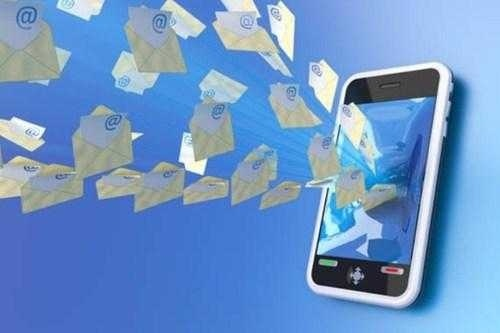

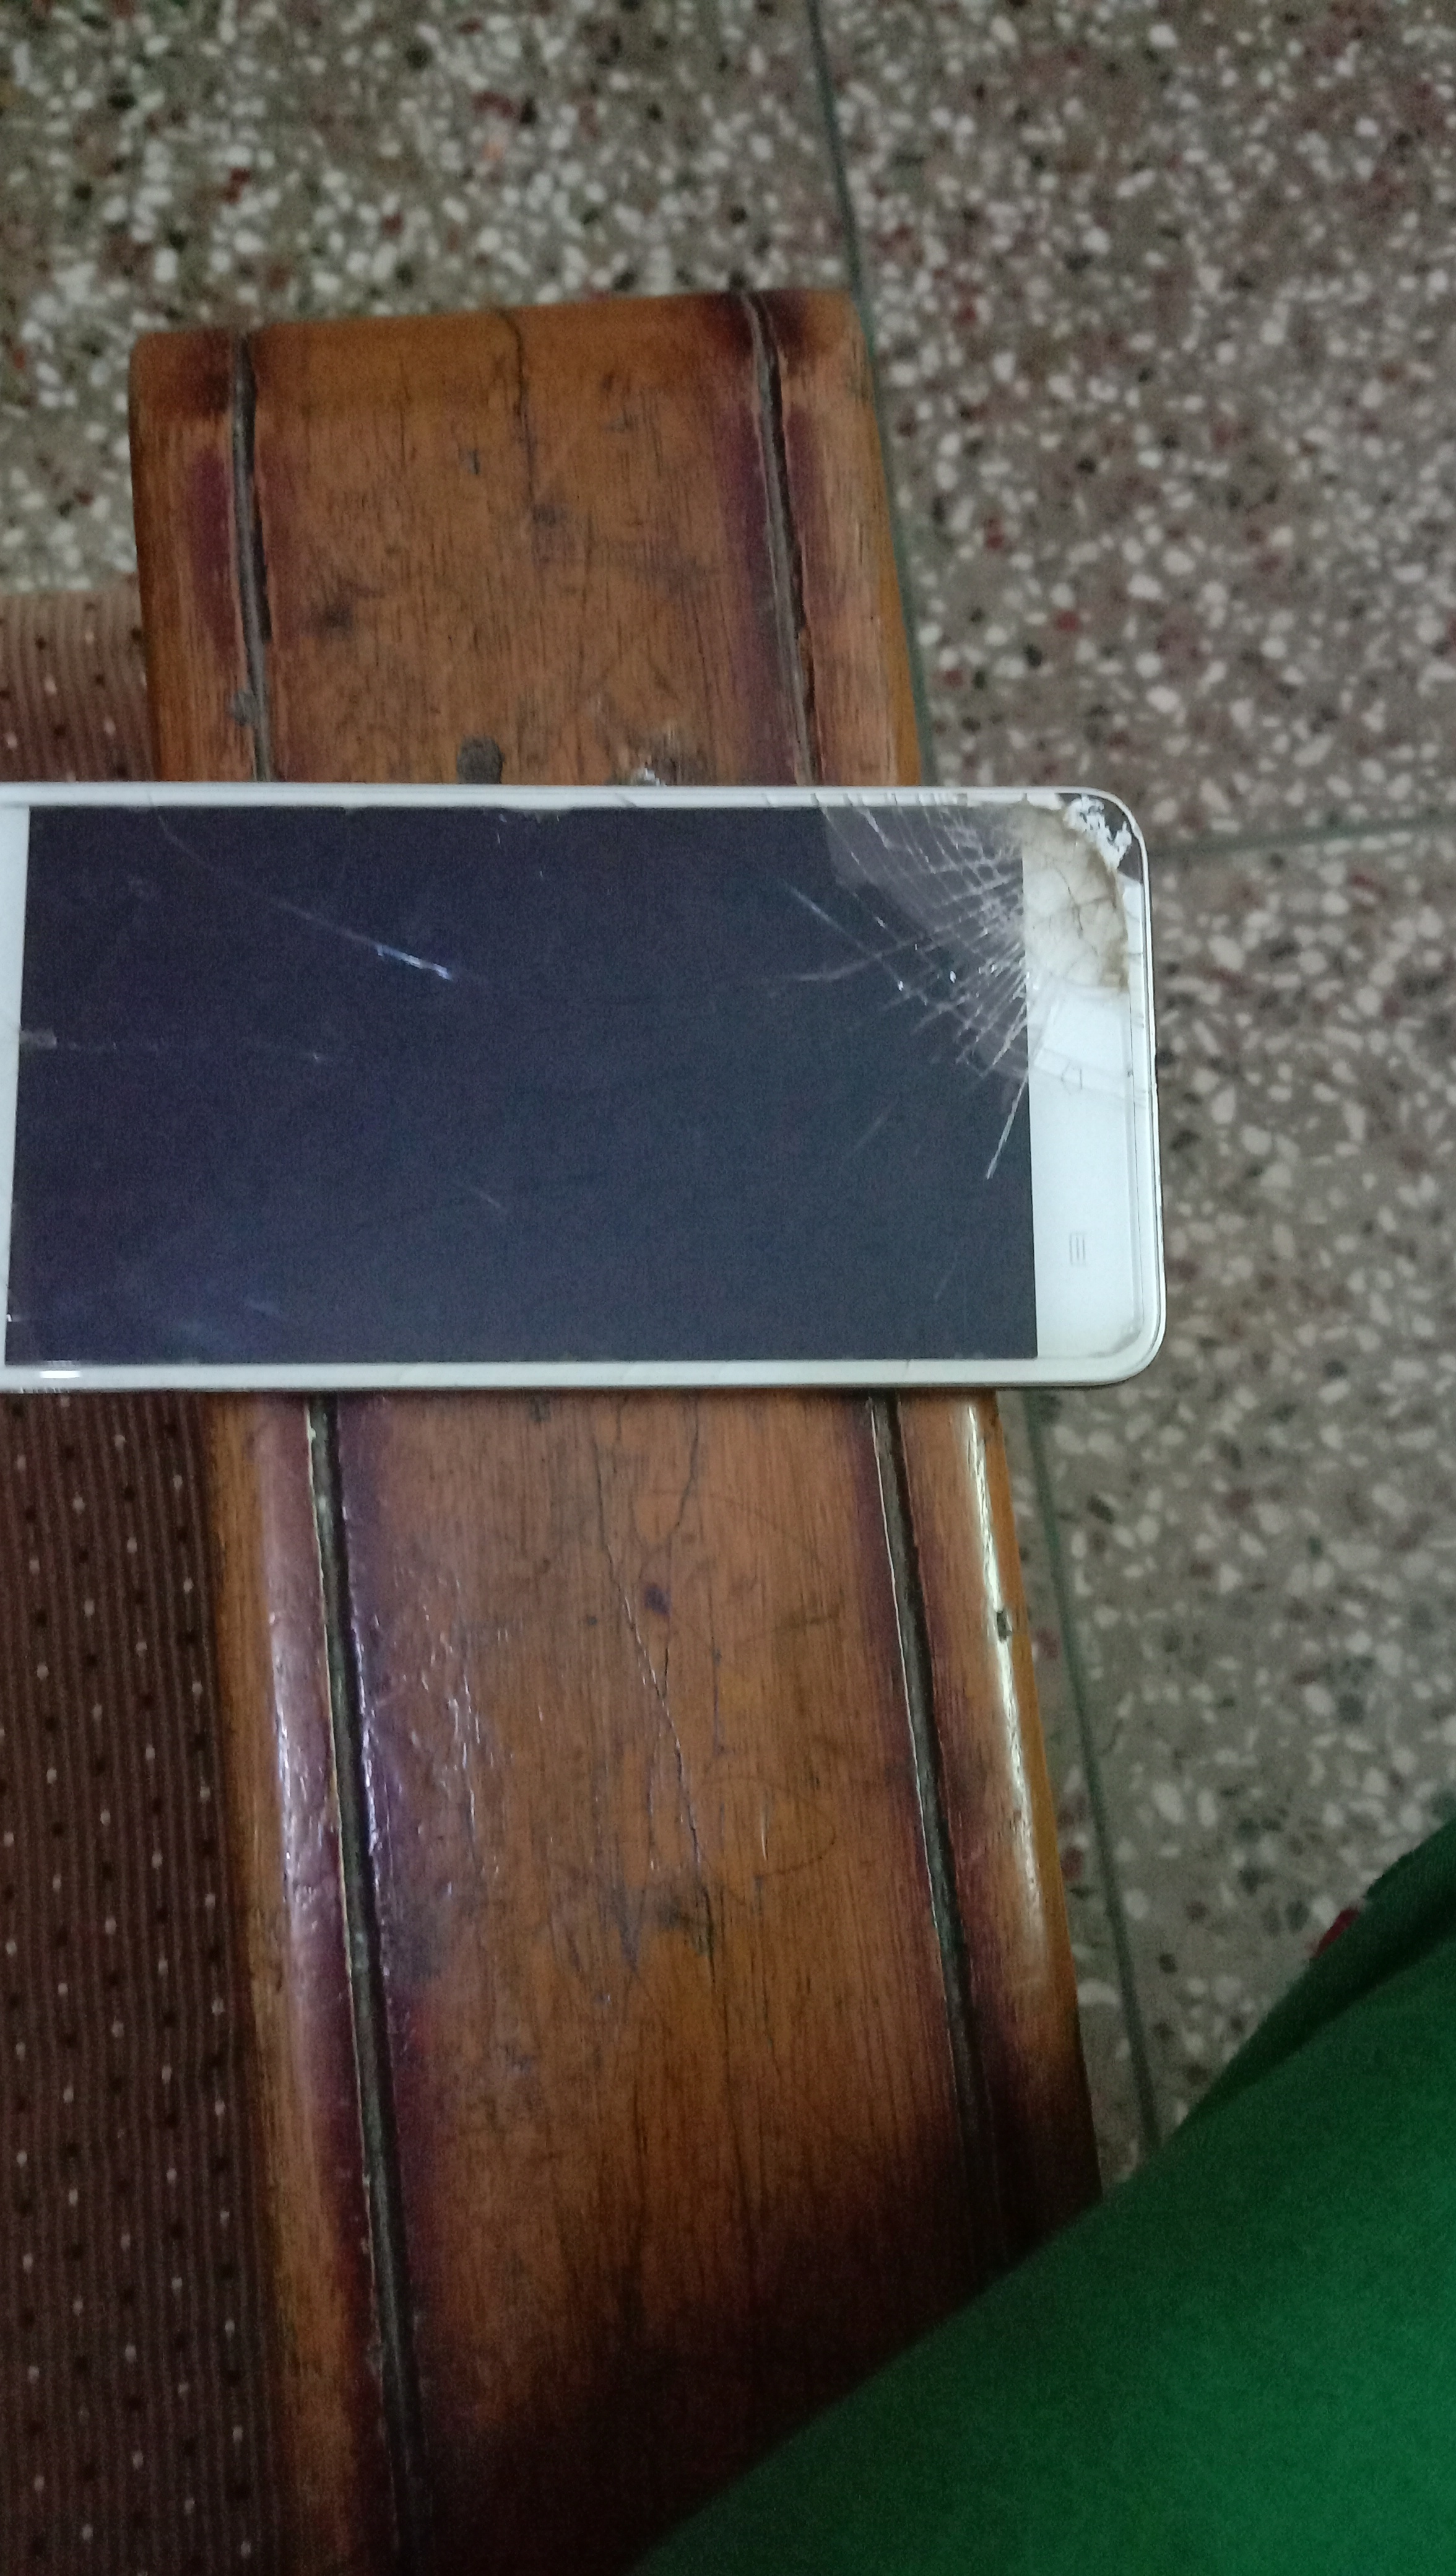

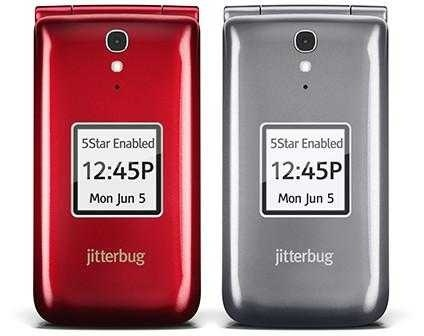

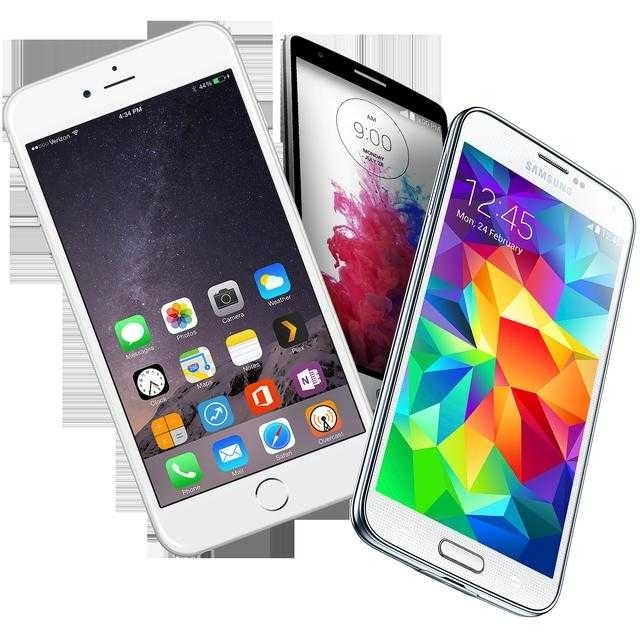

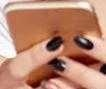

In [60]:
from IPython.display import Image, display
import glob

result_images = glob.glob("/content/threat_detection_results/*.jpg")

print("Quantidade de imagens processadas:", len(result_images))

for img in result_images[:5]:
    display(Image(filename=img))

## V2 - Avaliacao robusta e deploy em tempo real

Nesta secao, vamos adicionar:
- Metricas completas (mAP, precision, recall)
- Sweep de threshold por IoU
- Logica temporal anti-flicker para video/webcam
- Registro de evidencias para auditoria
- Exportacao ONNX e benchmark de latencia/FPS

In [ ]:
# Dependencias para avaliacao e visualizacao
!pip install -q scikit-learn seaborn matplotlib pandas onnx onnxruntime

In [ ]:
import os
import glob
import time
import json
import csv
from pathlib import Path
from collections import deque

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ultralytics import YOLO

### 1) Avaliacao completa de deteccao

In [ ]:
# Resolve automaticamente o caminho do melhor modelo
candidate_weights = [
    "/content/runs/mobile_phone_detector/weights/best.pt",
    "/content/runs/mobile_phone_detector-2/weights/best.pt",
]
found = [p for p in candidate_weights if os.path.exists(p)]

if not found:
    found = sorted(glob.glob("/content/runs/**/weights/best.pt", recursive=True))

if not found:
    raise FileNotFoundError("Nenhum best.pt encontrado em /content/runs")

best_weights_path = found[-1]
print("Usando pesos:", best_weights_path)
best_model = YOLO(best_weights_path)

# Metricas oficiais do Ultralytics no split de validacao
val_metrics = best_model.val(
    data="/content/mobile_phone_yolo/data.yaml",
    split="val",
    imgsz=640,
    conf=0.001,
    iou=0.6,
    plots=True,
    save_json=False,
    verbose=True,
)

print("\nResumo de metricas:")
print("mAP50:", float(val_metrics.box.map50))
print("mAP50-95:", float(val_metrics.box.map))
print("Precision:", float(val_metrics.box.mp))
print("Recall:", float(val_metrics.box.mr))

### 2) Sweep de threshold (IoU >= 0.5)

Seleciona automaticamente um threshold de confianca com base em Precision, Recall e F1.

In [ ]:
def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    x1 = (xc - w / 2.0) * img_w
    y1 = (yc - h / 2.0) * img_h
    x2 = (xc + w / 2.0) * img_w
    y2 = (yc + h / 2.0) * img_h
    return [x1, y1, x2, y2]


def compute_iou(box_a, box_b):
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b

    inter_x1 = max(xa1, xb1)
    inter_y1 = max(ya1, yb1)
    inter_x2 = min(xa2, xb2)
    inter_y2 = min(ya2, yb2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, xa2 - xa1) * max(0.0, ya2 - ya1)
    area_b = max(0.0, xb2 - xb1) * max(0.0, yb2 - yb1)
    union = area_a + area_b - inter_area

    return inter_area / union if union > 0 else 0.0


def load_gt_boxes(label_path, img_w, img_h):
    gt = []
    if not os.path.exists(label_path):
        return gt

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id, xc, yc, w, h = parts
            cls_id = int(float(cls_id))
            xc, yc, w, h = map(float, [xc, yc, w, h])
            gt.append((cls_id, yolo_to_xyxy(xc, yc, w, h, img_w, img_h)))
    return gt


def evaluate_thresholds(model, images_dir, labels_dir, thresholds, iou_thr=0.5):
    image_paths = sorted(glob.glob(os.path.join(images_dir, "*.jpg")) + glob.glob(os.path.join(images_dir, "*.png")))
    rows = []

    for conf_thr in thresholds:
        tp = 0
        fp = 0
        fn = 0

        for img_path in image_paths:
            img = cv2.imread(img_path)
            if img is None:
                continue

            img_h, img_w = img.shape[:2]
            stem = Path(img_path).stem
            lbl_path = os.path.join(labels_dir, f"{stem}.txt")
            gt = load_gt_boxes(lbl_path, img_w, img_h)

            preds = []
            result = model.predict(img, conf=float(conf_thr), verbose=False)[0]
            if result.boxes is not None and len(result.boxes) > 0:
                xyxy = result.boxes.xyxy.cpu().numpy()
                cls = result.boxes.cls.cpu().numpy().astype(int)
                confs = result.boxes.conf.cpu().numpy()
                for b, c, cf in zip(xyxy, cls, confs):
                    preds.append((int(c), b.tolist(), float(cf)))

            gt_used = [False] * len(gt)
            pred_used = [False] * len(preds)

            for pi, (p_cls, p_box, _) in enumerate(preds):
                best_iou = 0.0
                best_gi = -1
                for gi, (g_cls, g_box) in enumerate(gt):
                    if gt_used[gi] or p_cls != g_cls:
                        continue
                    iou = compute_iou(p_box, g_box)
                    if iou > best_iou:
                        best_iou = iou
                        best_gi = gi

                if best_gi >= 0 and best_iou >= iou_thr:
                    gt_used[best_gi] = True
                    pred_used[pi] = True
                    tp += 1

            fp += sum(1 for used in pred_used if not used)
            fn += sum(1 for used in gt_used if not used)

        precision = tp / (tp + fp + 1e-9)
        recall = tp / (tp + fn + 1e-9)
        f1 = 2 * precision * recall / (precision + recall + 1e-9)
        rows.append({
            "conf": conf_thr,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    return pd.DataFrame(rows)


thresholds = np.round(np.arange(0.10, 0.95, 0.05), 2)
metrics_df = evaluate_thresholds(
    model=best_model,
    images_dir="/content/mobile_phone_yolo/images/val",
    labels_dir="/content/mobile_phone_yolo/labels/val",
    thresholds=thresholds,
    iou_thr=0.5,
)

best_row = metrics_df.sort_values("f1", ascending=False).iloc[0]
print("Melhor threshold por F1:", float(best_row["conf"]))
print(best_row[["precision", "recall", "f1"]])

plt.figure(figsize=(10, 5))
plt.plot(metrics_df["conf"], metrics_df["precision"], label="precision")
plt.plot(metrics_df["conf"], metrics_df["recall"], label="recall")
plt.plot(metrics_df["conf"], metrics_df["f1"], label="f1", linewidth=2)
plt.xlabel("Confidence threshold")
plt.ylabel("Score")
plt.title("Sweep de threshold (IoU >= 0.5)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

metrics_df.head()

### 3) Inferencia em video/webcam com logica temporal, histerese e evidencias

In [ ]:
class TemporalThreatFilter:
    def __init__(self, window_size=20, trigger_ratio=0.60, release_ratio=0.30):
        self.window = deque(maxlen=window_size)
        self.trigger_ratio = trigger_ratio
        self.release_ratio = release_ratio
        self.alert_active = False

    def update(self, is_threat_frame):
        self.window.append(1 if is_threat_frame else 0)
        score = float(np.mean(self.window)) if len(self.window) else 0.0

        if score >= self.trigger_ratio:
            self.alert_active = True
        elif score < self.release_ratio:
            self.alert_active = False

        return self.alert_active, score


def run_realtime_detection(
    model,
    source=0,
    conf_thr=0.35,
    output_video="/content/threat_realtime_output.mp4",
    evidence_dir="/content/threat_evidence",
    log_csv="/content/threat_events.csv",
    cooldown_frames=45,
):
    os.makedirs(evidence_dir, exist_ok=True)
    filter_state = TemporalThreatFilter(window_size=20, trigger_ratio=0.6, release_ratio=0.3)

    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        raise RuntimeError("Nao foi possivel abrir a webcam/video. Verifique o source.")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 30.0
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_video, fourcc, fps, (w, h))

    frame_idx = 0
    cooldown = 0

    with open(log_csv, "w", newline="", encoding="utf-8") as f:
        csv_writer = csv.writer(f)
        csv_writer.writerow(["frame", "timestamp_sec", "alert_score", "max_conf", "evidence_path"])

        while True:
            ok, frame = cap.read()
            if not ok:
                break

            result = model.predict(frame, conf=conf_thr, verbose=False)[0]
            frame_has_threat = False
            max_conf = 0.0

            if result.boxes is not None and len(result.boxes) > 0:
                for b in result.boxes:
                    x1, y1, x2, y2 = map(int, b.xyxy[0].tolist())
                    conf = float(b.conf[0].item())
                    max_conf = max(max_conf, conf)

                    threat = is_threat((x1, y1, x2, y2), w, h)
                    if threat:
                        frame_has_threat = True
                        color = (0, 0, 255)
                        label = f"THREAT {conf:.2f}"
                    else:
                        color = (0, 255, 0)
                        label = f"mobile_phone {conf:.2f}"

                    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                    cv2.putText(frame, label, (x1, max(30, y1 - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

            alert, score = filter_state.update(frame_has_threat)
            timestamp_sec = frame_idx / fps

            if alert:
                overlay = frame.copy()
                cv2.rectangle(overlay, (0, 0), (w, h), (0, 0, 0), -1)
                frame = cv2.addWeighted(overlay, 0.55, frame, 0.45, 0)
                cv2.putText(frame, "ALERTA DE AMEACA", (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (255, 255, 255), 3)
                cv2.putText(frame, f"score_temporal={score:.2f}", (30, 95), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

                if cooldown <= 0:
                    evidence_path = os.path.join(evidence_dir, f"frame_{frame_idx:06d}.jpg")
                    cv2.imwrite(evidence_path, frame)
                    csv_writer.writerow([frame_idx, round(timestamp_sec, 3), round(score, 4), round(max_conf, 4), evidence_path])
                    cooldown = cooldown_frames

            if cooldown > 0:
                cooldown -= 1

            writer.write(frame)
            frame_idx += 1

    cap.release()
    writer.release()
    print("Processamento concluido.")
    print("Video de saida:", output_video)
    print("Evidencias:", evidence_dir)
    print("Log CSV:", log_csv)


# Exemplos de uso:
# 1) Webcam local (fora do Colab):
# run_realtime_detection(best_model, source=0)
#
# 2) Arquivo de video:
# run_realtime_detection(best_model, source="/content/seu_video.mp4")

### 4) Hard negative mining (coletar falsos positivos)

Salva amostras em que o modelo detectou celular, mas nao existe label no ground truth. Essas amostras ajudam muito no proximo ciclo de retreino.

In [ ]:
def collect_hard_negatives(model, images_dir, labels_dir, out_dir, conf_thr=0.35):
    os.makedirs(out_dir, exist_ok=True)
    img_paths = sorted(glob.glob(os.path.join(images_dir, "*.jpg")) + glob.glob(os.path.join(images_dir, "*.png")))

    saved = 0
    for img_path in img_paths:
        stem = Path(img_path).stem
        lbl_path = os.path.join(labels_dir, f"{stem}.txt")

        has_gt = os.path.exists(lbl_path) and os.path.getsize(lbl_path) > 0
        if has_gt:
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue

        pred = model.predict(img, conf=conf_thr, verbose=False)[0]
        has_pred = pred.boxes is not None and len(pred.boxes) > 0

        if has_pred:
            save_path = os.path.join(out_dir, os.path.basename(img_path))
            cv2.imwrite(save_path, img)
            saved += 1

    print(f"Hard negatives salvos: {saved}")
    print("Diretorio:", out_dir)


collect_hard_negatives(
    model=best_model,
    images_dir="/content/mobile_phone_yolo/images/val",
    labels_dir="/content/mobile_phone_yolo/labels/val",
    out_dir="/content/hard_negatives",
    conf_thr=0.35,
)

### 5) Exportacao ONNX e benchmark de inferencia

In [ ]:
# Exporta o modelo para ONNX
onnx_path = best_model.export(format="onnx", dynamic=True, simplify=True)
print("Modelo ONNX exportado em:", onnx_path)


def benchmark_model(model, image_paths, conf=0.35):
    times = []
    for p in image_paths:
        img = cv2.imread(p)
        if img is None:
            continue

        t0 = time.perf_counter()
        _ = model.predict(img, conf=conf, verbose=False)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000.0)

    if not times:
        print("Sem imagens validas para benchmark.")
        return

    avg_ms = float(np.mean(times))
    p95_ms = float(np.percentile(times, 95))
    fps = 1000.0 / avg_ms if avg_ms > 0 else 0.0

    print(f"Latencia media: {avg_ms:.2f} ms/frame")
    print(f"Latencia p95:   {p95_ms:.2f} ms/frame")
    print(f"FPS estimado:   {fps:.2f}")


bench_imgs = sorted(glob.glob("/content/mobile_phone_yolo/images/val/*.jpg"))[:100]
benchmark_model(best_model, bench_imgs, conf=0.35)